# Fighting Overfitting — L2 (weight decay), then Dropout + BatchNorm in `MyNN`

In the Last demo, our `MyNN` network overfit: its train accuracy ended up far above its test accuracy.

Here we keep **everything the same** (same widths, same lr=0.1, same 100 epochs, same training loop) and add regularization **in two parts**:
1. **Baseline** — train the original `MyNN` with no regularization.
2. **Part 1 — L2 regularization:** same `MyNN`, we only switch on `weight_decay` in the optimizer. *(changes how we train)*
3. **Part 2 — Dropout + BatchNorm:** we add `nn.Dropout()` and `nn.BatchNorm1d()` **inside the same `MyNN` class**, keeping L2 on. *(changes the model itself)*
4. After **each** model we check train/test accuracy and plot its **per-epoch train vs test curves** next to the previous step. At the end we compare all three **side by side**.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)


In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


## Load the data
Same Fashion-MNIST training file as the GPU demo.

In [ ]:
# Fetches directly (no upload). Note: LFS 'media' host, not 'raw'.
url = 'https://media.githubusercontent.com/media/fpleoni/fashion_mnist/master/fashion-mnist_train.csv'
df = pd.read_csv(url)
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

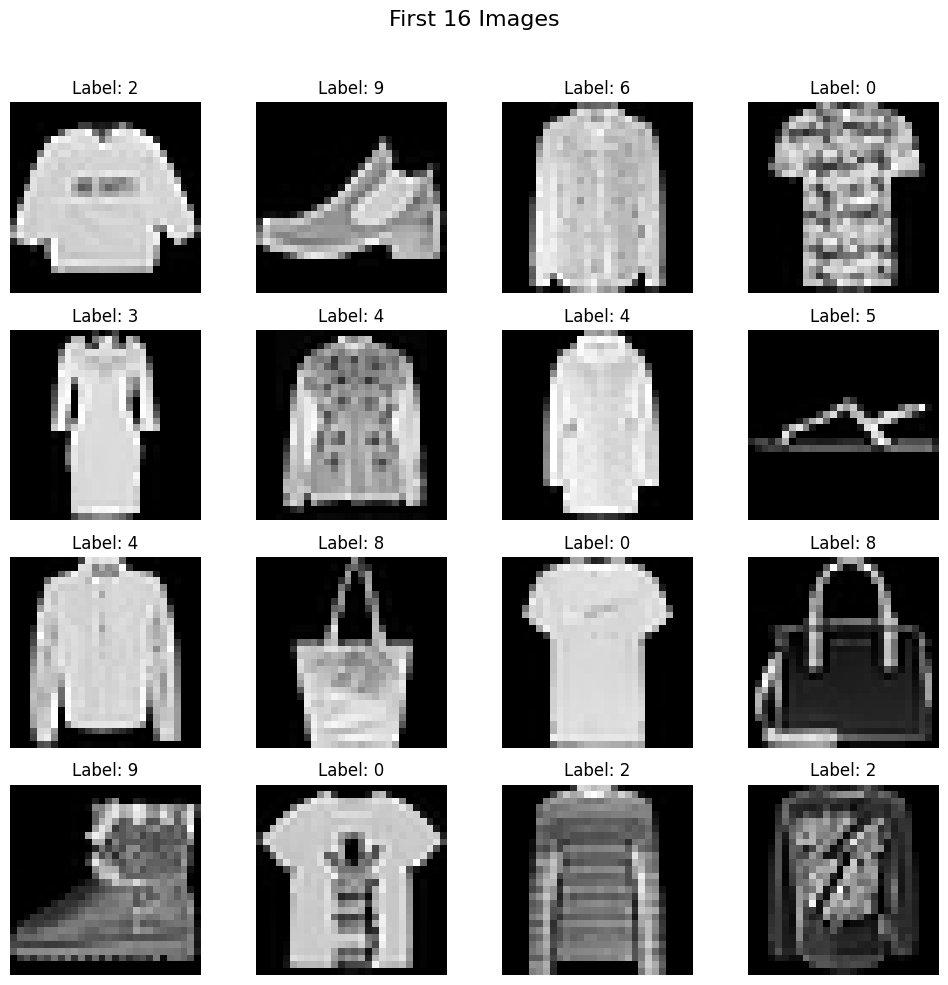

In [ ]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img, cmap='gray')  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# scale pixels to 0-1
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

# bigger batches used ONLY for measuring accuracy/loss every epoch (no gradients -> fast, results identical)
train_eval_loader = DataLoader(train_dataset, batch_size=1024, shuffle=False, pin_memory=True)
test_eval_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False, pin_memory=True)

print(f'train images: {len(train_dataset)} , test images: {len(test_dataset)}')

train images: 48000 , test images: 12000


### Helper: measure loss + accuracy on a dataset
We call this **after every epoch** on both train and test data, so we can plot how the gap grows over time.
It always switches to `model.eval()` so Dropout is off and BatchNorm uses its running statistics.

In [ ]:
def evaluate(model, data_loader):
  model.eval()  # turn off Dropout, use BatchNorm's saved running stats

  total_loss_sum = 0.0      # running sum of loss across ALL images seen so far
  correct_predictions = 0   # running count of correctly classified images
  total_images = 0          # running count of how many images we've checked

  with torch.no_grad():  # we're only measuring performance, not training -> no gradients needed
    for images, true_labels in data_loader:
      images, true_labels = images.to(device), true_labels.to(device)

      predicted_scores = model(images)  # raw class scores for each image (a batch_size x 10 matrix)

      # criterion gives the AVERAGE loss for this batch -> multiply by batch size to get the batch's TOTAL loss
      batch_size = true_labels.shape[0]
      total_loss_sum += criterion(predicted_scores, true_labels).item() * batch_size

      predicted_labels = predicted_scores.argmax(dim=1)  # pick the class with the highest score, per image
      correct_predictions += (predicted_labels == true_labels).sum().item()

      total_images += batch_size

  average_loss = total_loss_sum / total_images
  accuracy = correct_predictions / total_images
  return average_loss, accuracy

### Helper: plot per-epoch train vs test curves
`plot_curves(runs)` draws **one column per model** (top row = accuracy, bottom row = loss):
- **Solid line = train, dashed line = test.** The **shaded band** between them is the overfitting gap.
- All panels in a row share the **same y-axis**, so band widths can be compared directly across models.
- `runs` is a list of `(name, history, color)` — pass one model, or several to compare them side by side.

**Why we compare the average of the last 10 epochs.** With lr=0.1 and batch size 32, accuracy jumps up and down from one epoch to the next — the gap at the final epoch alone can be noticeably higher or lower just by luck. So whenever we *compare* models (gap printouts, table, bar chart, plot titles) we use the **average of the last 10 epochs**, like judging a batter by their average over the last 10 innings instead of only the last one.

In [ ]:
#@title plot_curves functions (click to expand)
N_LAST = 10  # compare models using the average of the last 10 epochs (one noisy epoch can't flip the result)

def avg_last(history, key, n=N_LAST):
  return sum(history[key][-n:]) / n

def plot_curves(runs, acc_ylim=(0.75, 1.0)):
  epoch_range = range(1, len(runs[0][1]['train_acc']) + 1)

  # 2 rows (accuracy, loss) x one column per model; sharey='row' -> same scale across models
  fig, axes = plt.subplots(2, len(runs), figsize=(5.5 * len(runs) + 1, 8),
                           sharex=True, sharey='row', squeeze=False)

  for col, (name, history, color) in enumerate(runs):
    ax_acc, ax_loss = axes[0, col], axes[1, col]

    # accuracy: train vs test, gap shaded
    ax_acc.plot(epoch_range, history['train_acc'], color=color, label='train')
    ax_acc.plot(epoch_range, history['test_acc'], color=color, linestyle='--', label='test')
    ax_acc.fill_between(epoch_range, history['test_acc'], history['train_acc'], color=color, alpha=0.2, label='gap')
    avg_gap = avg_last(history, 'train_acc') - avg_last(history, 'test_acc')
    ax_acc.set_title(f'{name}\ngap (avg last {N_LAST} epochs): {avg_gap:.4f}')
    ax_acc.set_ylim(*acc_ylim)  # fixed range -> accuracy plots look the same scale across the whole notebook
    ax_acc.grid(alpha=0.3)

    # loss: train vs test, gap shaded
    ax_loss.plot(epoch_range, history['train_loss'], color=color, label='train')
    ax_loss.plot(epoch_range, history['test_loss'], color=color, linestyle='--', label='test')
    ax_loss.fill_between(epoch_range, history['train_loss'], history['test_loss'], color=color, alpha=0.2, label='gap')
    ax_loss.set_xlabel('Epoch')
    ax_loss.grid(alpha=0.3)

  axes[0, 0].set_ylabel('Accuracy')
  axes[1, 0].set_ylabel('Cross-entropy loss')
  axes[0, 0].legend(loc='lower right')
  axes[1, 0].legend(loc='upper right')
  fig.suptitle('Train vs Test per epoch', fontsize=14)
  plt.tight_layout()
  plt.show()

  # where did each model's test accuracy peak?
  for name, history, _ in runs:
    best_epoch = max(epoch_range, key=lambda e: history['test_acc'][e - 1])
    print(f"{name.ljust(28)} best test acc {history['test_acc'][best_epoch - 1]:.4f} at epoch {best_epoch:>3} , "
          f"avg test acc (last {N_LAST} epochs) {avg_last(history, 'test_acc'):.4f}")

## Baseline — `MyNN` with no regularization
The same network from the GPU demo. It will overfit.

In [ ]:
class MyNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):

    return self.model(x)


In [ ]:
learning_rate = 0.1
epochs = 100
  # L2 strength (lambda), used in Part 1 and Part 2. Too small -> no visible effect, too large -> underfits

In [ ]:
# instantiate + train the baseline
torch.manual_seed(42)  # same starting weights + same batch order for both models -> fair comparison
model = MyNN(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)  # no weight_decay -> no L2

base_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(epochs):
  model.train()  # training mode
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    loss = criterion(outputs, batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss += loss.item()

  # record train + test performance after this epoch
  train_loss, train_acc = evaluate(model, train_eval_loader)
  test_loss, test_acc = evaluate(model, test_eval_loader)
  base_history['train_loss'].append(train_loss)
  base_history['test_loss'].append(test_loss)
  base_history['train_acc'].append(train_acc)
  base_history['test_acc'].append(test_acc)

  if (epoch + 1) % 10 == 0:
    print(f'Epoch: {epoch + 1} , Loss: {total_epoch_loss/len(train_loader):.4f} , '
          f'train acc: {train_acc:.4f} , test acc: {test_acc:.4f}')

Epoch: 10 , Loss: 0.2764 , train acc: 0.9008 , test acc: 0.8773
Epoch: 20 , Loss: 0.2113 , train acc: 0.9251 , test acc: 0.8848
Epoch: 30 , Loss: 0.1682 , train acc: 0.9239 , test acc: 0.8761
Epoch: 40 , Loss: 0.1410 , train acc: 0.9507 , test acc: 0.8874
Epoch: 50 , Loss: 0.1242 , train acc: 0.9588 , test acc: 0.8868
Epoch: 60 , Loss: 0.1001 , train acc: 0.9638 , test acc: 0.8883
Epoch: 70 , Loss: 0.0859 , train acc: 0.9718 , test acc: 0.8878
Epoch: 80 , Loss: 0.0773 , train acc: 0.9737 , test acc: 0.8884
Epoch: 90 , Loss: 0.0714 , train acc: 0.9745 , test acc: 0.8855
Epoch: 100 , Loss: 0.0631 , train acc: 0.9797 , test acc: 0.8857


Evaluate the baseline on train vs test.

In [ ]:
model.eval()  # evaluation mode

# accuracy on the final trained model (a single snapshot, right now)
_, base_train_acc = evaluate(model, train_eval_loader)
_, base_test_acc = evaluate(model, test_eval_loader)
print(f'final epoch          -> train: {base_train_acc:.4f} , test: {base_test_acc:.4f}')

# accuracy jumps between epochs, so for comparing models we use the average of the last 10 epochs
base_train_avg = avg_last(base_history, 'train_acc')
base_test_avg = avg_last(base_history, 'test_acc')
print(f'avg last {N_LAST} epochs -> train: {base_train_avg:.4f} , test: {base_test_avg:.4f} , gap: {base_train_avg - base_test_avg:.4f}')

final epoch          -> train: 0.9797 , test: 0.8857
avg last 10 epochs -> train: 0.9787 , test: 0.8878 , gap: 0.0909


### Baseline curves — where does memorizing start?
- Does **train** accuracy keep climbing toward 100% while **test** accuracy flattens out? The shaded band keeps widening.
- Look at the loss: does **test loss** stop falling — or even start **rising** — while train loss keeps dropping? That is the model fitting noise in the training set.
- Around which epoch does the test curve stop improving? Every epoch after that mostly improves *train* accuracy only.

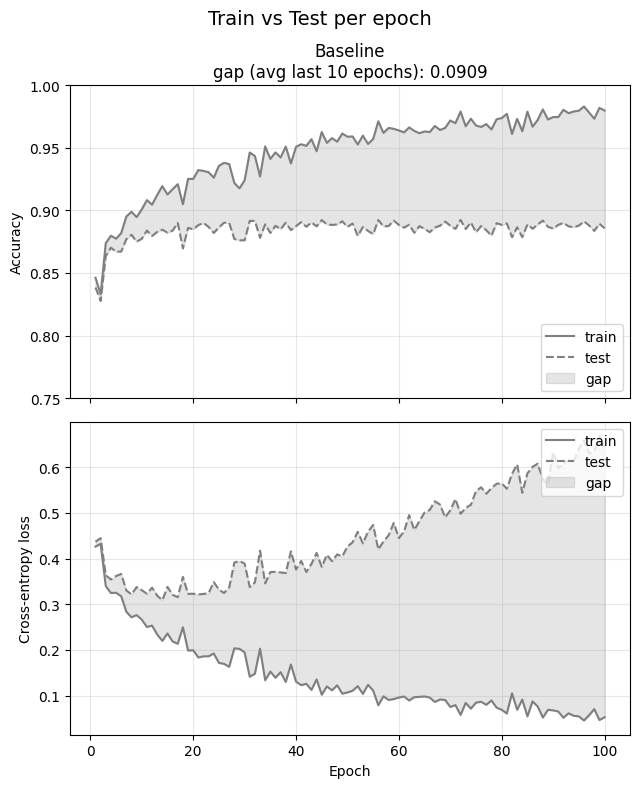

Baseline                     best test acc 0.8923 at epoch  72 , avg test acc (last 10 epochs) 0.8878


In [ ]:
plot_curves([('Baseline', base_history, 'tab:gray')])

## Part 1 — L2 regularization (weight decay)

**Same `MyNN` class, same training loop.** The only change is one argument in the optimizer: `weight_decay`.

L2 regularization adds a penalty for large weights to the loss:

$$\text{Loss} = \text{CrossEntropy} + \frac{\lambda}{2} \sum w^2$$

With SGD, `weight_decay=λ` does exactly this: every step, each weight is also pulled a little towards zero. Large weights let the network fit tiny details (noise) of the training set, so keeping weights small pushes the model towards simpler, smoother decision boundaries.

Question to think about before running: *should train accuracy go up or down? What about the gap?*